# Chicago Crime and SocioEconomic Data

The data comes from the Chicago data portal. The crime data from [this](https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2/about_data) page, while the socioeconomic data from [this](https://data.cityofchicago.org/Health-Human-Services/Selected-socioeconomic-indicators-by-neighborhood/i9hv-en6g/about_data) page.



## The Data

The crime data is composed of the following columns:
'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location'

Before starting this notebook I opened the crime file in VIM and removed the spaces from the column headings made up of more than one word to make working with the data easier. The columns of a lazy data frame are read only so this seemed the easiest way to make the change. For the census data I made the modifications in the code below.

For the crimes dataset I use the *scan_csv* over the *read_csv* method to create a lazy dataframe as the file is 2.3GB in size and I don't think my laptop would appreciate opening this normally.

For the census data I use *read_csv* as it's a small file, and I attatch the census data only once having processed the crime data from its raw state into summarised data frames.

In [45]:
# Import the libraries
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import statsmodels.api as sm

# Load the two dataframes. The change in crime category names below is because the old title is used
# at the beginning of the dataset, but changes to the new value towards the end of the dataset.
crime_df = pl.scan_csv(
    'data/chicago-crime/Crimes_-_2001_to_Present_20260822.csv').with_columns(
        PrimaryType=pl.col("PrimaryType").replace("CRIM SEXUAL ASSAULT", "CRIMINAL SEXUAL ASSAULT")
    )

census_df = pl.read_csv(
    'data/chicago-crime/Census_Data_-_Selected_socioeconomic_indicators_in_Chicago,_2008_–_2012_20260822.csv'
)

# Alter the census data column headings for ease of use and standardise column for joining with crime data (CommunityArea)
census_df.columns = [
    'CommunityArea',
    'CommunityAreaName',
    'PercentHousingCrowded',
    'PercentHouseholdsBelowPovery',
    'PercentAged16AboveUnemployed',
    'PercentAged25AboveWithoutHighSchoolDiploma',
    'PercentAgedUnder18OrOver64',
    'PerCapitaIncome',
    'HardshipIndex']

    

A note on both dataframes. Their connection is the numeric value 'CommunityArea', which is called the same in both dataframes after the above changes. Both tables have rows where the value is empty/Null. The rows with the empty value for 'CommunityArea' stands for the area of the whole of Chicago. These values are removed 

In the cell below I remove the null values, as these have no corresponding census data, which is what we want to compare among areas.

Finally, in the crime dataframe there is an entry for the 'CommunityArea' of 0. There are only 76 crimes recorded under this value, so a very small amount in the scheme of things. While there is no corresponding 'CommunityArea' in the census data, there is location data for the crimes including the Block they were commited on, of which there are only five distinct entries. As these have no census data connected to them, and that is what we want to use for comparisons, these too are removed.

In [46]:
# Remove data that has no census area from both datasets

crime_df = crime_df.with_columns(
    pl.col("CommunityArea").fill_null(-1),
).filter(pl.col("CommunityArea") > 0)

census_df = census_df.with_columns(
    pl.col("CommunityArea").fill_null(-1)
).filter(pl.col("CommunityArea") > 0)

## Looking at the data: Census

I became aware of this dataset when working through a module on the EDx IBM Data Engineering specialisation. The plot that really stood out was the one below, linking the income of an area versus the hardship index. It shows a stark trend of descreasing hardship as the income increases.

Text(0, 0.5, 'Hardship Index')

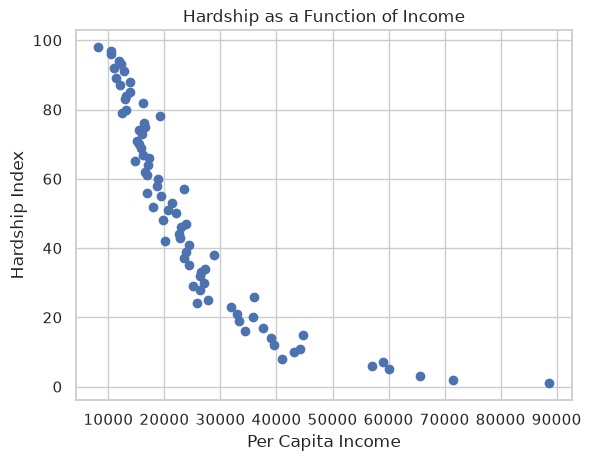

In [47]:
fig, ax = plt.subplots()
ax.scatter(census_df['PerCapitaIncome'], 
            census_df['HardshipIndex'])
            
ax.set_title("Hardship as a Function of Income")
ax.set_xlabel("Per Capita Income")
ax.set_ylabel("Hardship Index")

Looking at some of the other attributes that go toward the hardship index, those of the housing being crowded, being below povery, unemployment, and lacking a high school diploma we see in the figures below. 

While not as stark a relationship as the hardship vs income one above, there is a clear signal in each of the figures showing a trend for increasing negative census indicators as income decreases.

Text(0.5, 0.98, 'Per Capita Income vs Census Indicators')

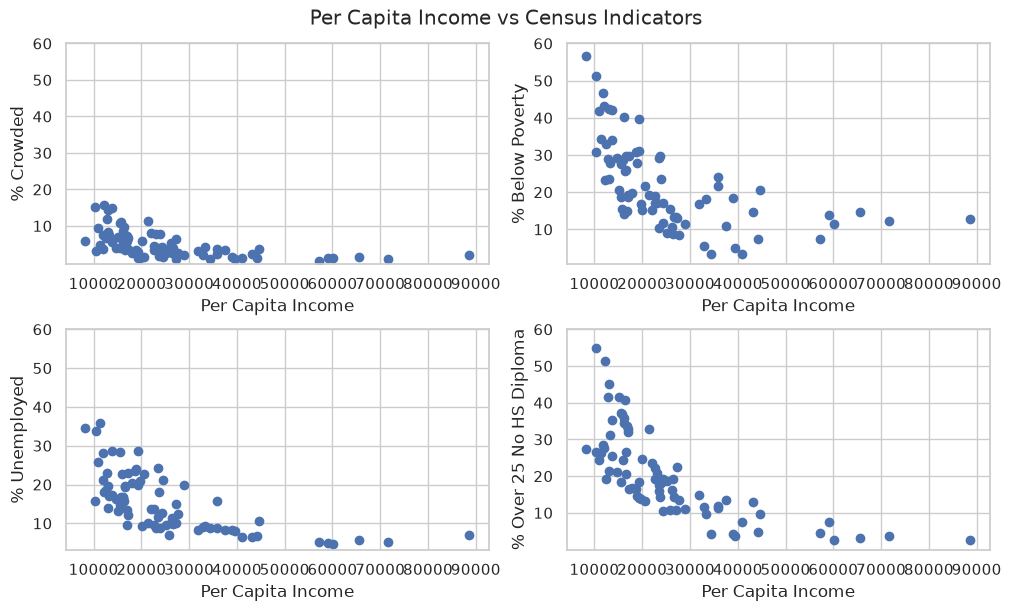

In [48]:
# Create four named Axes for displaying the sub-plots

fig, axd = plt.subplot_mosaic([['crowded', 'poverty'],
                               ['unemployed', 'diploma']],
                              figsize=(10, 6), layout="constrained")
# For each axis plot the related data and set the y-axis label, the x-axis label and y-axis ticks are the same for every plot
for k, ax in axd.items():
    if k == 'crowded':
        ax.scatter(census_df['PerCapitaIncome'],
                    census_df['PercentHousingCrowded'])
        ax.set_ylabel("% Crowded")    
    if k == 'poverty':
        ax.scatter(census_df['PerCapitaIncome'],
                    census_df['PercentHouseholdsBelowPovery'])
        ax.set_ylabel("% Below Poverty")            
    if k == 'unemployed':
        ax.scatter(census_df['PerCapitaIncome'],
                    census_df['PercentAged16AboveUnemployed'])
        ax.set_ylabel("% Unemployed")
    if k == 'diploma':
        ax.scatter(census_df['PerCapitaIncome'],
                    census_df['PercentAged25AboveWithoutHighSchoolDiploma'])
        ax.set_ylabel("% Over 25 No HS Diploma")
    ax.set_xlabel("Per Capita Income")
    ax.set_yticks([10, 20, 30, 40, 50, 60])
fig.suptitle('Per Capita Income vs Census Indicators')

What is surpising given the trends in the above charts is that there are around 18% below poverty in the area earning in the $80,000 to $90,000 income bracket, while there is a lower percentage in poverty in the $23,000 $45,000 bracket. I think to understand this it is necessary to have more domain knowledge, to know more about the make up and demographic of the area.

## Looking at the data: Crime

Looking at the data below we can see that there are 8,005,432 crimes recorded in areas that are repesented in the census data over 26 years. The amount of distinct crime catagories is 33. There are a number of crime categories that have no values for a number of years, some at the start of recording, some at the end of recording. I assume that some categories were introduced after publishing the data was started, and some were retired (or no crimes in that category were committed) partway along recording.

In [49]:
# Create a summary calculating the number of crimes for every distinct crime type

count_by_type_df = crime_df.sql("""
    SELECT PrimaryType, COUNT(ID) AS NumberOfCrimes
    FROM self
    GROUP BY PrimaryType
""").collect().sort("NumberOfCrimes", descending=True)


number_of_crimes = sum(count_by_type_df["NumberOfCrimes"])
print(f"Number of crimes committed total: {number_of_crimes}")

number_of_crime_types = count_by_type_df.shape
print(f"Number of distinct crime categories: {number_of_crime_types[0]}")



Number of crimes committed total: 8005432
Number of distinct crime categories: 32


In the plot below all the instances of distinct crimes are summed and displayed by crime category, using a log scale for the y-axis. In total over the twenty five years there were over a million instances each of thefts, battery, and criminal damage. Whereas at the other end of the scale there was around ten instances of ritualism.

Text(0.5, 0.98, 'Number of Crimes by Category 2001 to 2026')

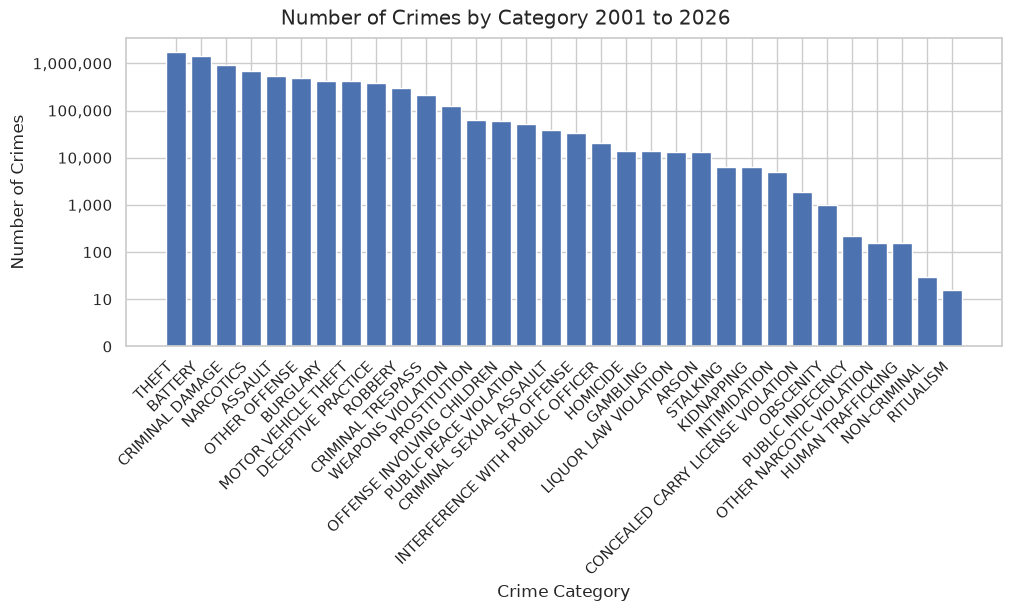

In [50]:
count_by_type_log_df = count_by_type_df.with_columns(
        pl.col("NumberOfCrimes").log(10).alias("LogNumberOfCrimes")
)

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

ax.bar(count_by_type_log_df["PrimaryType"],
        count_by_type_log_df["LogNumberOfCrimes"])
ax.tick_params("x", rotation=45, rotation_mode="xtick")
ax.set_yticks([0, 1, 2, 3, 4, 5, 6 ], labels=['0', '10', '100', '1,000', '10,000', '100,000', '1,000,000'])
ax.set_xlabel("Crime Category")
ax.set_ylabel("Number of Crimes")
fig.suptitle("Number of Crimes by Category 2001 to 2026")

In the plot below we look at the top four highest crimes in the dataset.  There looks to be a seaonal element to theft and battery, and a smaller signal in the criminal damage category. As shown by the box plots there is a very large spread of data in all these categories, for example theft in June ranges from around 4,000 to 10,000 over all the years.

Only the years 2003 to 2025 inclusive are included in the following plots as we only want years with full data.

To get a better idea of the variability in the data we will look at the same data in timeseries fashion.

Text(0.5, 1.0, 'Number of Crimes by Month 2003 to 2025')

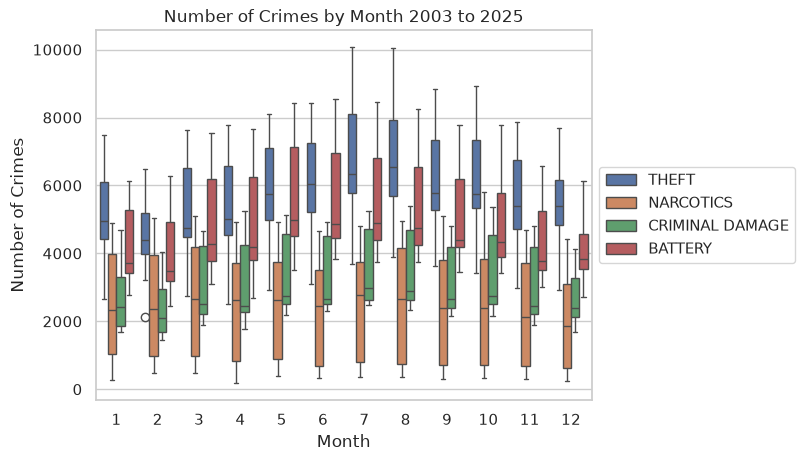

In [51]:
# Parse the date-time column to allow extraction of datetime based attributes
dated_crime_df = crime_df.with_columns(
    pl.col("Date").str.to_datetime("%m/%d/%Y %I:%M:%S %p").alias("dt")
)

# Create month and year columns, sum all crimes grouped by these and the primary type column,
# filter out the crimes and years we don't want.
yearly_monthly_crime_df = dated_crime_df.with_columns(
    (pl.col(name="dt").dt.month().alias("bucket_month")),
    (pl.col("dt").dt.year().alias("bucket_year"))
).group_by(
    ["PrimaryType", "bucket_year", "bucket_month"]
).len("NumberOfCrimes").filter(
    (pl.col("PrimaryType").is_in(["THEFT", "BATTERY", "CRIMINAL DAMAGE", "NARCOTICS"])) &
    (pl.col("bucket_year").is_between(2003, 2025))
).collect()

# Create a df that simply has the number of crimes per primary type each year
yearly_crime_df = yearly_monthly_crime_df.drop("bucket_month").group_by(
    ["PrimaryType", "bucket_year"]
).sum()

ax = sns.boxplot(data=yearly_monthly_crime_df, x="bucket_month", y="NumberOfCrimes", hue="PrimaryType")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xlabel("Month")
ax.set_ylabel("Number of Crimes")
ax.set_title("Number of Crimes by Month 2003 to 2025")


In the plot below the four highest crime categories are plotted over time, with crime counts aggregated to the year level. There is an extrememly strong trend of decreasing crime incidents as time passes. At first I thought maybe I had done someting wrong because it's such a change, but after looking at a basic plot of all crime per year, it showed the same trend.

I think also the dip in thefts around 2020 is due to Covid restrictions.

Text(0.5, 1.0, 'Number of Crimes by Year 2003 to 2025')

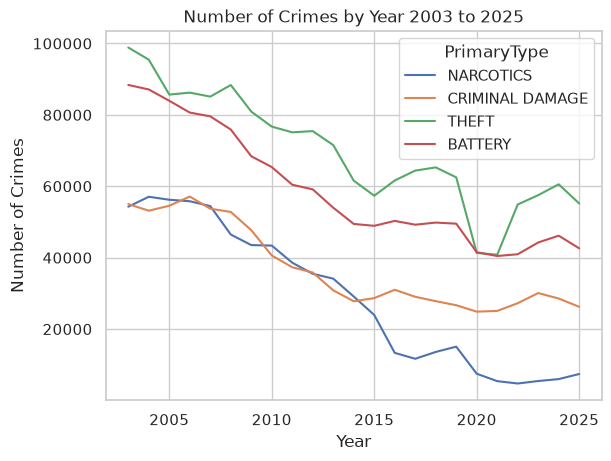

In [52]:
ax =sns.lineplot(data=yearly_crime_df, x="bucket_year", y="NumberOfCrimes", hue="PrimaryType")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Crimes")
ax.set_title("Number of Crimes by Year 2003 to 2025")

The plot below shows all crimes aggregated together to create a total number of crimes committed per year chart. I created this to double check the downward trend.

Text(0.5, 1.0, 'Total Number of Crimes by Year 2003 to 2025')

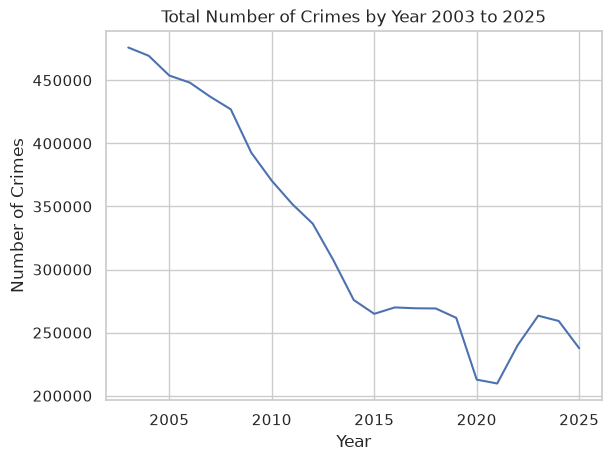

In [53]:
yearly_total_crime_df = dated_crime_df.with_columns(
    pl.col("dt").dt.year().alias("bucket_year")
).group_by(
    ["bucket_year"]
).len("NumberOfCrimes").filter(
    pl.col("bucket_year").is_between(2003, 2025)
).collect()


ax =sns.lineplot(data=yearly_total_crime_df, x="bucket_year", y="NumberOfCrimes")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Crimes")
ax.set_title("Total Number of Crimes by Year 2003 to 2025")


Lastly we plot the yearly aggregates for every crime type to see if they all display a downward trend. The highest recorded crimes reduce, but the lower recorded ones fluctuate. The 

Text(0.5, 1.0, 'Number of Crimes by Year 2003 to 2025')

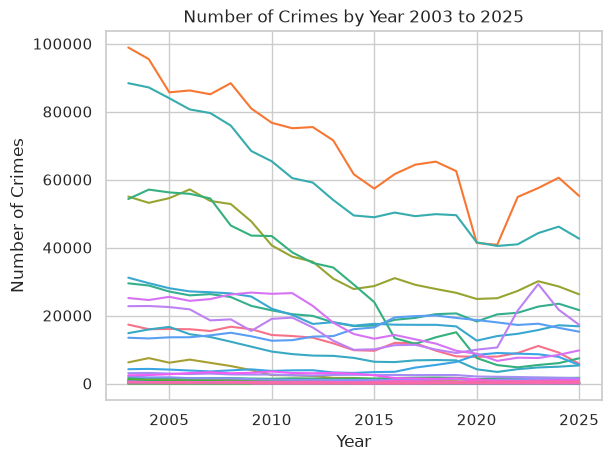

In [54]:
yearly_total_crime_df = dated_crime_df.with_columns(
    pl.col("dt").dt.year().alias("bucket_year")
).group_by(
    ["PrimaryType", "bucket_year"]
).len("NumberOfCrimes").filter(
    pl.col("bucket_year").is_between(2003, 2025)
).collect()


ax =sns.lineplot(data=yearly_total_crime_df, x="bucket_year", y="NumberOfCrimes", hue="PrimaryType", legend=False)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Crimes")
ax.set_title("Number of Crimes by Year 2003 to 2025")

Though there is a downward trend, some crimes seem to be increasing somewhat towards the end. In the table below we can see some of the crime categories that had an increase in reported instances between 2023 and 2025, there are thirteen in total.

In [55]:
# Get aggregate values for crimes by type and year, pivot so the years are the column headings,
# cast the aggregates as signed ints (from unsigned) to allow the difference to be taken
# sorting by difference size

end_increase_crime_df = dated_crime_df.with_columns(
    pl.col("dt").dt.year().alias("bucket_year")
).group_by(
    ["PrimaryType", "bucket_year"]
).len("NumberOfCrimes").filter(
    pl.col("bucket_year").is_between(2023, 2025)
).collect().pivot(on="bucket_year", values="NumberOfCrimes").with_columns(
    (pl.col("2023").cast(pl.Int32).alias("2023")),
    (pl.col("2025").cast(pl.Int32).alias("2025"))
).with_columns(
     (pl.col("2025") - pl.col("2023")).alias("difference")
).sort(pl.col("difference"), descending=True).drop("2024")

print(end_increase_crime_df.head(10))

shape: (10, 4)
┌─────────────────────────────────┬───────┬───────┬────────────┐
│ PrimaryType                     ┆ 2023  ┆ 2025  ┆ difference │
│ ---                             ┆ ---   ┆ ---   ┆ ---        │
│ str                             ┆ i32   ┆ i32   ┆ i32        │
╞═════════════════════════════════╪═══════╪═══════╪════════════╡
│ BURGLARY                        ┆ 7494  ┆ 9740  ┆ 2246       │
│ NARCOTICS                       ┆ 5455  ┆ 7418  ┆ 1963       │
│ OTHER OFFENSE                   ┆ 15732 ┆ 16830 ┆ 1098       │
│ CRIMINAL TRESPASS               ┆ 4722  ┆ 5326  ┆ 604        │
│ INTERFERENCE WITH PUBLIC OFFIC… ┆ 586   ┆ 916   ┆ 330        │
│ PUBLIC PEACE VIOLATION          ┆ 862   ┆ 1056  ┆ 194        │
│ CONCEALED CARRY LICENSE VIOLAT… ┆ 205   ┆ 277   ┆ 72         │
│ STALKING                        ┆ 534   ┆ 579   ┆ 45         │
│ LIQUOR LAW VIOLATION            ┆ 186   ┆ 200   ┆ 14         │
│ OBSCENITY                       ┆ 42    ┆ 55    ┆ 13         │
└─────────

We saw in the plot above, Number of Crimes Per Year 2003 to 2025 that crimes could be put into two categories: those that start high and get lower as time progresses, and those that roughly stay the same throughout the differing years. Eyeballing the data, it seems that those that end in 2025 above 1,000 crimes are those that reduced, while those below 1,000 crimes stayed pretty much the same over time.

In the plot below we can compare the number of occurrences of the crime types that seemed to change over time, with their 2003 count and their 2025 count beside each other. The plot shows that nearly all crimes in this selection ended lower than their starting position, except for Deceptive Practices and Weapons Violation, however their increases are miniscule.

Text(0.5, 0.98, 'Number of Crimes Compared between 2003 and 2025')

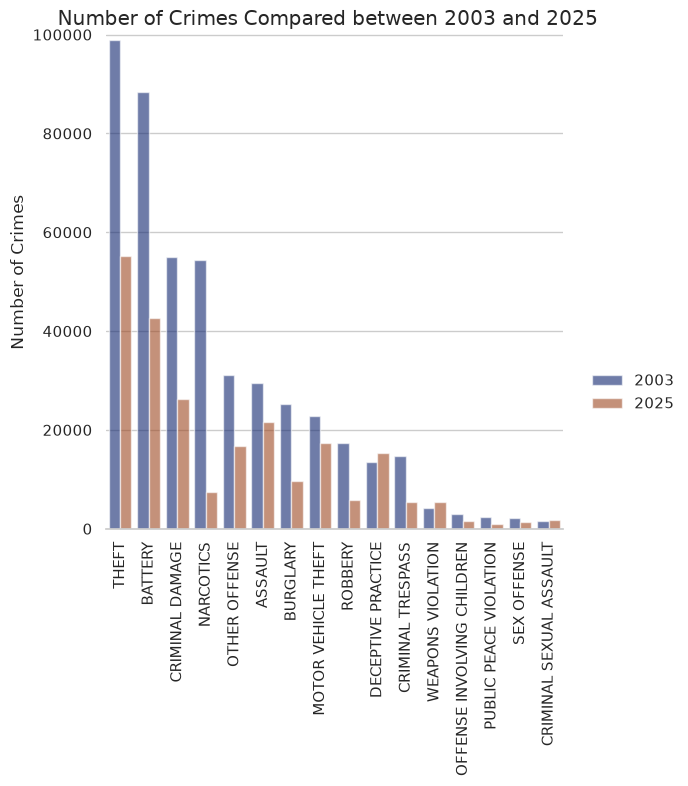

In [56]:
# Get a list of crime categories that ended in 2025 with a cumulative total over 1000
filter_crimes = dated_crime_df.with_columns(
    pl.col("dt").dt.year().alias("bucket_year")
).group_by(
    ["PrimaryType", "bucket_year"]
).len("NumberOfCrimes").filter(
    (pl.col("bucket_year") == 2025) & (pl.col("NumberOfCrimes") > 1000)
).collect().get_column("PrimaryType").to_list()

# Get the number of crimes per year per crime category for the crime categories wanted
two_year_crime_df = dated_crime_df.with_columns(
    pl.col("dt").dt.year().alias("bucket_year")
).group_by(
    ["PrimaryType", "bucket_year"]
).len("NumberOfCrimes").filter(
    pl.col("PrimaryType").is_in(filter_crimes)
).sort(pl.col("NumberOfCrimes"), descending=True).filter(
    pl.col("bucket_year").is_in([2003, 2025])
).collect()

sns.set_theme(style="whitegrid")

ax = sns.catplot(
    data=two_year_crime_df, kind="bar",
    x="PrimaryType", y="NumberOfCrimes", hue="bucket_year",
    errorbar="sd", palette="dark", alpha=.6, height=6
)
ax.despine(left=True)
ax.set_axis_labels("", "Number of Crimes")
ax.legend.set_title("")
ax.tick_params("x", rotation=90, rotation_mode="xtick")
ax.fig.suptitle("Number of Crimes Compared between 2003 and 2025")


Continuing to look at the years 2003 and 2025, the below plot compares the arrest ratio for the same crimes as in the plot above. Now with the above plot showing a reduction, and in some places a very large reduciton, I though that the arrest ratio would go up in 2025 compared 2003 as I thought that would lower the incidence of crime. However that is not the case. For most crime categories the arrest rate was higher in 2003 than 2025.

This graph also shows that except for Narcotics, Weapons Violation, and Criminal Trespass the ratio of arrests is very low.  Criminal Damage, Burglary, and Robbery are the categories where an arrest is unlikely to be made.

Text(0.5, 0.98, 'Arrest Ratio Compared between 2003 and 2025')

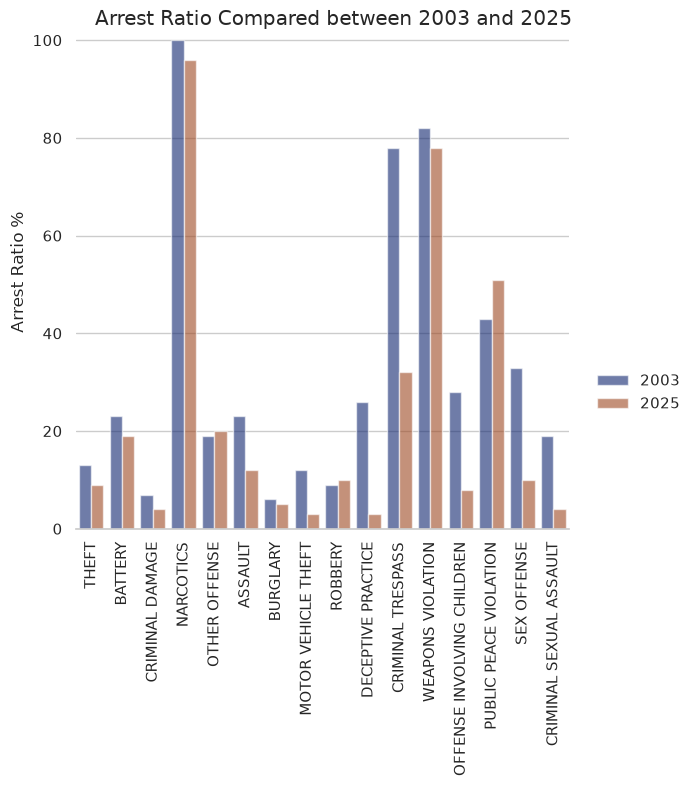

In [57]:
arrest_ratio_df =dated_crime_df.with_columns(
    pl.col("dt").dt.year().alias("bucket_year")
).group_by(
    ["PrimaryType", "bucket_year"]).agg(
        [pl.len().alias("NumberOfCrimes"), pl.sum("Arrest").alias("NumberOfArrests")]
    ).filter(
        (pl.col("PrimaryType").is_in(filter_crimes)) &
        (pl.col("bucket_year").is_in([2003, 2025]))
    ).with_columns(
        (
            ((pl.col("NumberOfArrests") / pl.col("NumberOfCrimes"))*100).round(0)
        ).alias("ArrestRatio")
    ).sort(pl.col("NumberOfCrimes"), descending=True).collect()

ax = sns.catplot(
    data=arrest_ratio_df, kind="bar",
    x="PrimaryType", y="ArrestRatio", hue="bucket_year",
    errorbar="sd", palette="dark", alpha=.6, height=6
)
ax.despine(left=True)
ax.set_axis_labels("", "Arrest Ratio %")
ax.legend.set_title("")
ax.tick_params("x", rotation=90, rotation_mode="xtick")
ax.fig.suptitle("Arrest Ratio Compared between 2003 and 2025")

## Looking at the data: Crime and Census

In this section we compare the crime data along with the census data, so we can see if there are any links between the two data sets.

In [76]:
# Create a summary calculating the number of crimes for every distinct community area
count_by_area_df = crime_df.sql("""
   SELECT DISTINCT CommunityArea, COUNT(ID) AS NumberOfCrimes
   FROM self
   GROUP BY CommunityArea
   ORDER BY NumberOfCrimes DESC
""").collect().sort("NumberOfCrimes", descending=True)

# Create a summary calculating the number of crimes for every distinct combination of crime type and community area
count_by_type_and_area_df = crime_df.sql("""
    SELECT PrimaryType, CommunityArea, COUNT(ID) AS NumberOfCrimes
    FROM self
    GROUP BY PrimaryType, CommunityArea
    ORDER BY NumberOfCrimes DESC
""").collect().sort("NumberOfCrimes", descending=True)

# Reduce the census data to just the area information and hardship index
#area_census_df = census_df.select(["CommunityArea", "CommunityAreaName", "HardshipIndex"])

# Add the census data to the community summary to access the textual representation of the community and add datetime column
enriched_count_by_area_df = count_by_area_df.join(
    census_df, on="CommunityArea", how="inner").sort(pl.col("NumberOfCrimes"), descending=True)
enriched_count_by_area_and_type_df = count_by_type_and_area_df.join(
    census_df, on="CommunityArea", how="inner")

In the plot below the number of crimes is presented by area. Austin is by far the area with the highest crime rates. Interestingly the second highest rate is found in Near North Side, which is the area with the highest Per Capita Income in the census dataset.

Text(0.5, 0.98, 'Number of Crimes by Community Area 2001 to 2026')

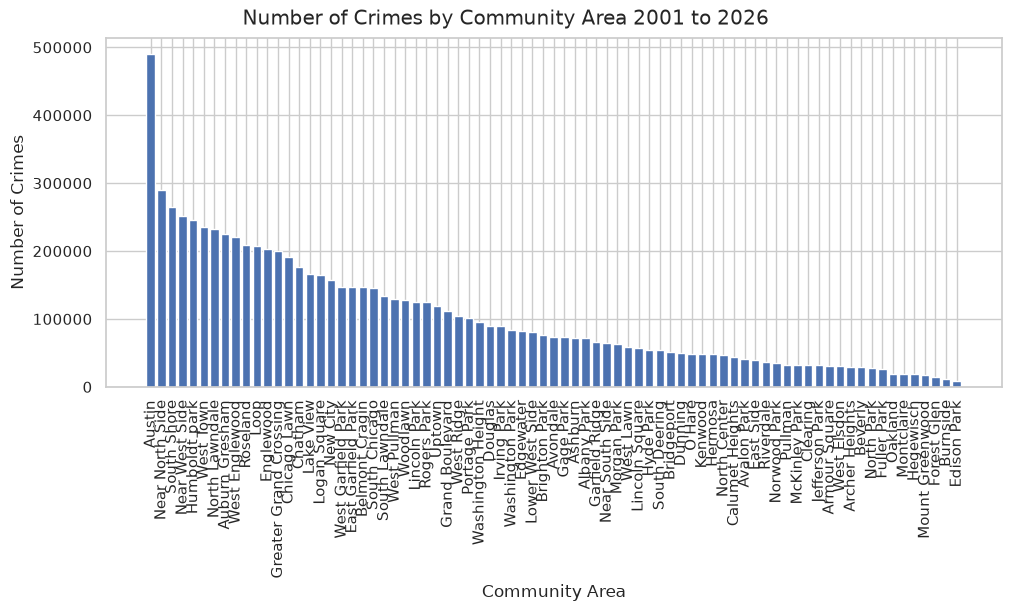

In [72]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

ax.bar(enriched_count_by_area_df["CommunityAreaName"],
        enriched_count_by_area_df["NumberOfCrimes"])
ax.tick_params("x", rotation=90, rotation_mode="xtick")
#ax.set_yticks([0, 1, 2, 3, 4, 5, 6 ], labels=['0', '10', '100', '1,000', '10,000', '100,000', '1,000,000'])
ax.set_xlabel("Community Area")
ax.set_ylabel("Number of Crimes")
fig.suptitle("Number of Crimes by Community Area 2001 to 2026")

In the plot below, alongside the crime tallies, a selection of the different census information is also plotted. Interestingly there doesn't seem to be a strong relationship between the amount of crime and the census information.

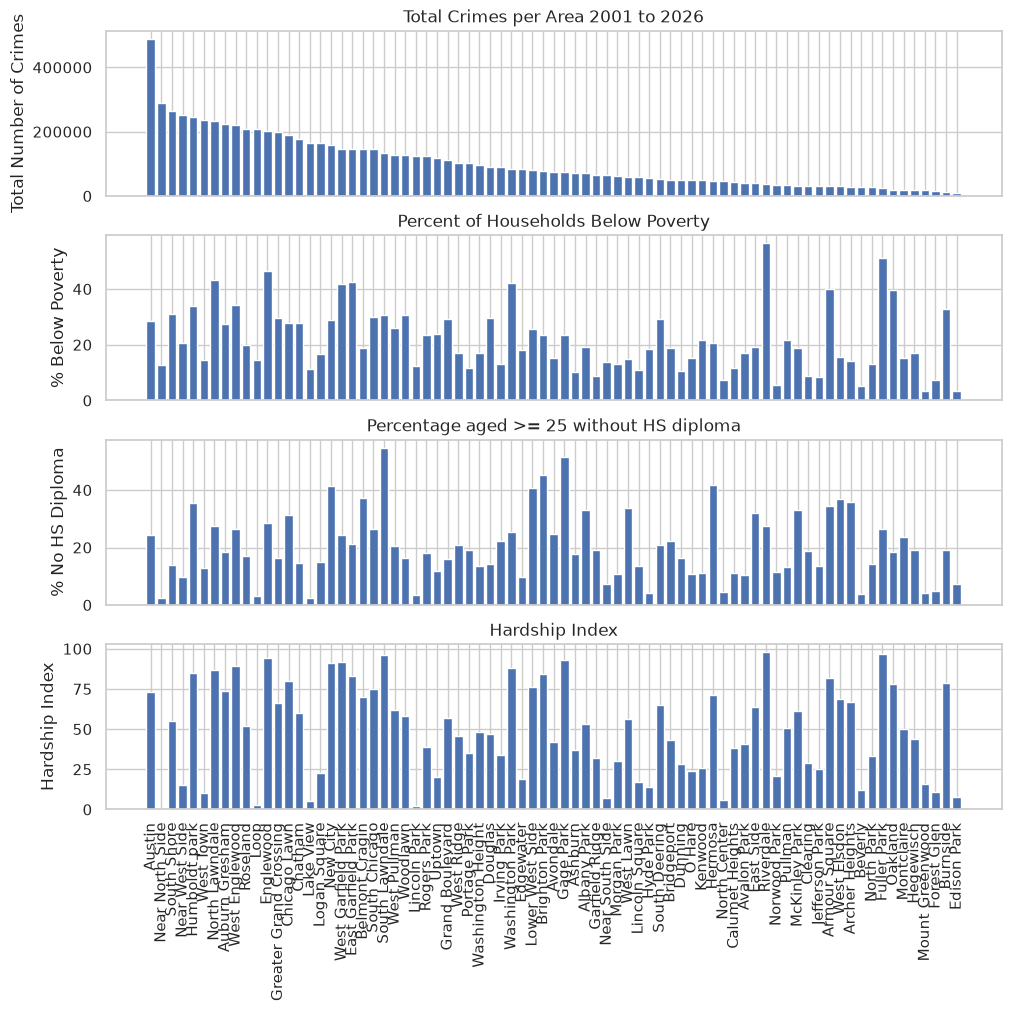

In [94]:
fig, axs = plt.subplots(ncols=1, nrows=4, layout="constrained",
                        figsize=(10, 10), sharex=True)

for plot_name in ["crime", "poverty", "education", "hardship"]:
    if plot_name == "crime":
        row = 0
        x= enriched_count_by_area_df["CommunityAreaName"]
        y = enriched_count_by_area_df["NumberOfCrimes"]
        title = "Total Crimes per Area 2001 to 2026"
        ylabel = "Total Number of Crimes"
    if plot_name == "poverty":
        row = 1
        x= enriched_count_by_area_df["CommunityAreaName"]
        y = enriched_count_by_area_df["PercentHouseholdsBelowPovery"]
        title = "Percent of Households Below Poverty"
        ylabel = "% Below Poverty"
    if plot_name == "education":
        row = 2
        x= enriched_count_by_area_df["CommunityAreaName"]
        y = enriched_count_by_area_df["PercentAged25AboveWithoutHighSchoolDiploma"]
        title = "Percentage aged >= 25 without HS diploma"
        ylabel = "% No HS Diploma"
    if plot_name == "hardship":
        row = 3 
        x= enriched_count_by_area_df["CommunityAreaName"]
        y = enriched_count_by_area_df["HardshipIndex"]
        title = "Hardship Index"
        ylabel = "Hardship Index"

    axs[row].bar(x, y)
    axs[row].tick_params("x", rotation=90, rotation_mode="xtick")
    axs[row].set_title(title)
    axs[row].set_ylabel(ylabel)


Looking at the seeminly random spread of hardship vs crime tallies, I decided to take a subset of the data. I wanted to spread my selection between crime tallies, poverty, education, and hardship index, so I make the selections manually rather than using a filter for hardship > 80 or such.

Austin will be selected for the most crimes, Edison Park for the least. Near North Side for the highest per capita, Riverdale for the least.

Chatham, South Lawndale, Albany Park, North Park.

Are there different crimes predominant in differing area types? e.g. affluent area crimes different from less affluent areas?



In [95]:
census_df.sort(pl.col("PerCapitaIncome"), descending=True).tail()

CommunityArea,CommunityAreaName,PercentHousingCrowded,PercentHouseholdsBelowPovery,PercentAged16AboveUnemployed,PercentAged25AboveWithoutHighSchoolDiploma,PercentAgedUnder18OrOver64,PerCapitaIncome,HardshipIndex
i64,str,f64,f64,f64,f64,f64,i64,i64
67,"""West Englewood""",4.8,34.4,35.9,26.3,40.7,11317,89
26,"""West Garfield Park""",9.4,41.7,25.8,24.5,43.6,10934,92
37,"""Fuller Park""",3.2,51.2,33.9,26.6,44.9,10432,97
30,"""South Lawndale""",15.2,30.7,15.8,54.8,33.8,10402,96
54,"""Riverdale""",5.8,56.5,34.6,27.5,51.5,8201,98


Below the census community area count is halved, by taking the first row, followed by every second value, which includes the highest and lowest crime areas, so as to display better in plots. This is possible as the data is already ordered in descending order of number of crimes committed in that area.

In [ ]:
reduced_census_df = census_df.filter(
    pl.col("CommunityAreaName").is_in([
        ""
    ])
)

# Add the census data to the community summary to access the textual representation of the community
reduced_enriched_count_by_area_df = count_by_area_df.join(
    reduced_census_df, on="CommunityArea", how="inner")
reduced_enriched_count_by_area_and_type_df = count_by_type_and_area_df.join(
    reduced_census_df, on="CommunityArea", how="inner")



Text(0.5, 0.98, 'Number of Crimes by Community Area 2001 to 2026')

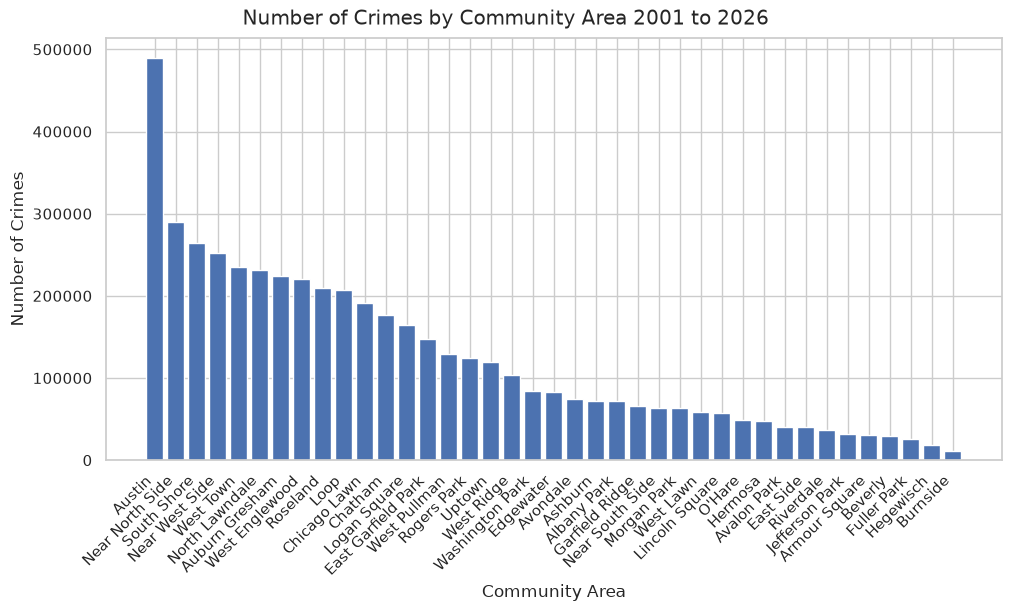

In [67]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

ax.bar(reduced_enriched_count_by_area_df["CommunityAreaName"],
        reduced_enriched_count_by_area_df["NumberOfCrimes"])
ax.tick_params("x", rotation=45, rotation_mode="xtick")
#ax.set_yticks([0, 1, 2, 3, 4, 5, 6 ], labels=['0', '10', '100', '1,000', '10,000', '100,000', '1,000,000'])
ax.set_xlabel("Community Area")
ax.set_ylabel("Number of Crimes")
fig.suptitle("Number of Crimes by Community Area 2001 to 2026")

Text(0.5, 1.0, 'Hardship Index by Area')

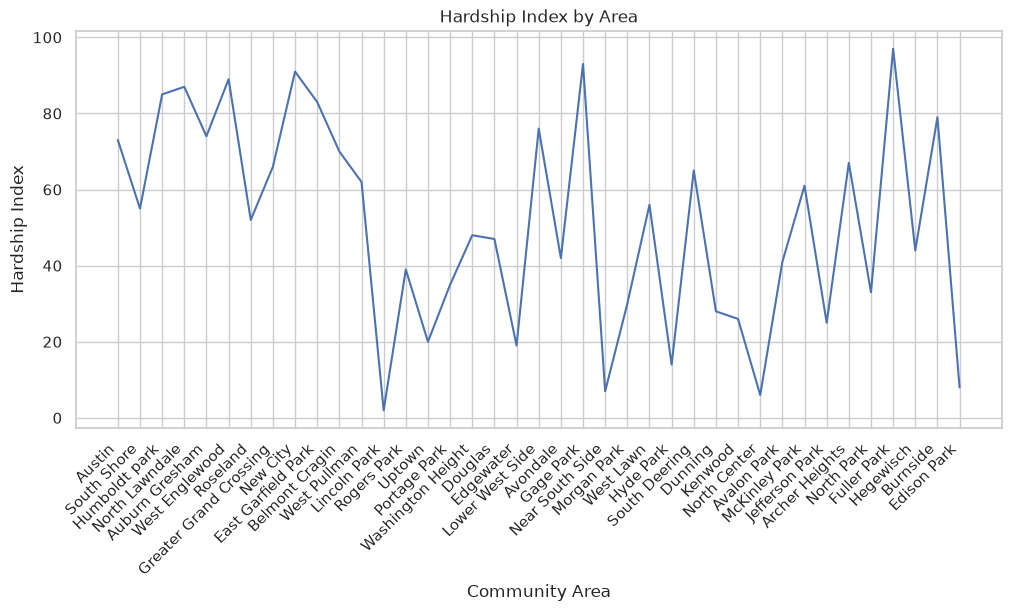

In [62]:
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.plot(reduced_enriched_count_by_area_df["CommunityAreaName"],
        reduced_enriched_count_by_area_df["HardshipIndex"])
ax.tick_params("x", rotation=45, rotation_mode="xtick")
ax.set_xlabel("Community Area")
ax.set_ylabel("Hardship Index")
ax.set_title("Hardship Index by Area")


In the plot below we can see there is a range of crimes in different income areas. Three stand out starkly, two for their total number of crimes, and a third for being in the highest category of income while also being the third highest in the dataset. We will look at these in particular. 

ColumnNotFoundError: "PerCapitaIncome" not found

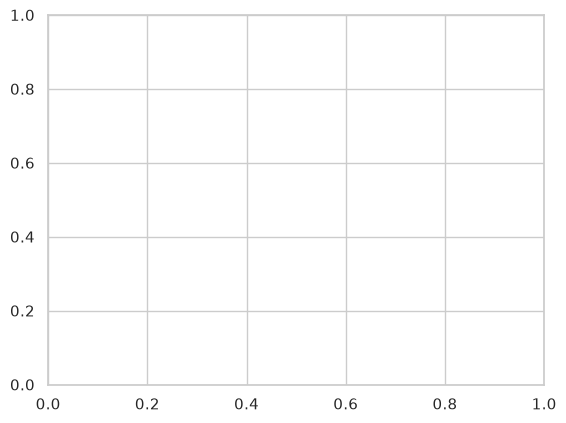

In [63]:
fig, ax = plt.subplots()
ax.scatter(enriched_count_by_area_df['PerCapitaIncome'], 
            enriched_count_by_area_df['NumberOfCrimes'])
            
ax.set_title("Crime by Area Income in City Areas")
ax.set_xlabel("Per Capita Income")
ax.set_ylabel("Number of Crimes")

As we can see below the largest outlier is the catch all area of Chicago, this was expected. The second highest is a surprise as it has around 200,000 more crimes reported than the next highest area.

In [ ]:
outliers = enriched_count_by_area_df.filter(pl.col("NumberOfCrimes") > 270000)
print(outliers)

Austin has the greatest amount of crimes by area outwith the city-wide category. Also interesting is the large number of crimes in the highest income area of Near North Side. Lets look at the top ten crimes for each of these areas.

In Austin the two highest values are Battery and Narcotics, with a gradual decline down the crime types as the number recorded decreases.

In Near North Side Theft is the highest value by far, around 80,000 instances more than the second position.

In [ ]:
austin_df = enriched_count_by_area_and_type_df.filter(pl.col("CommunityArea") == 25)
austin_df.head(10)

In [ ]:
near_north_df = enriched_count_by_area_and_type_df.filter(pl.col("CommunityArea") == 8)
near_north_df.head(10)

In the plot below we look at the number of occurrences of Theft in total for each level of Per Capita Income. As shown by the linear regression comparing thefts as a function of income, there is a positive correlation.

In [ ]:

# Here we filter out the Community Area zero value as this has no census data and causes the linear regression to fail
theft_df = enriched_count_by_area_and_type_df.filter(
    (pl.col("PrimaryType") == "THEFT") & (pl.col("CommunityArea") != 0)
)

fig, ax = plt.subplots()
ax.scatter(theft_df['PerCapitaIncome'], 
            theft_df['NumberOfCrimes'])
ax.set_title("Thefts by Per Capita Income in City Areas")
ax.set_xlabel("Per Capita Income")
ax.set_ylabel("Number of Thefts")

slope, intercept = np.polyfit(theft_df['PerCapitaIncome'],
                                                theft_df['NumberOfCrimes'],
                                                deg=1)
xseq = np.linspace(0, 90000, 10)
ax.plot(xseq, intercept + slope * xseq, color="k", lw=2.5)


Now lets look at theft in the Near North Side, over two years, plotted first by timeseries based on date, and then categorical on time buckets.

In [ ]:
# Filter the crime dataframe for the Near North Side area, and for the crime of Theft
near_north_theft_df = crime_df.filter(pl.col("CommunityArea") == 8).filter(pl.col("PrimaryType") == "THEFT").collect()
# Add a DateTime column parsed from the string Date field
near_north_theft_df = near_north_theft_df.with_columns(
    (pl.col("Date").str.to_datetime("%m/%d/%Y %I:%M:%S %p")).alias("dt"))

# Create the date, hour, and day of year bucket fields for use as the x axis field
near_north_theft_df = near_north_theft_df.with_columns(    
    (pl.col("dt").dt.date().alias("bucket_date")),
    (pl.col(name="dt").dt.hour().alias("bucket_hour")),
    (pl.col("dt").dt.ordinal_day().alias("doy")),
    (pl.col(name="dt").dt.year().alias("bucket_year"))
    )

# Create the aggregate count by date filtered for two years taken at random
near_north_theft_date_df = near_north_theft_df.filter(
        pl.col("dt").is_between(datetime(2001,1,1), datetime(2026,12,31))
    ).group_by(["bucket_date"]).len(name="NumberOfCrimes")  

fig, ax = plt.subplots()
ax.scatter(near_north_theft_date_df['bucket_date'], 
            near_north_theft_date_df['NumberOfCrimes'])
ax.set_title("Thefts per Day in Near North Side (2004 and 2006)")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Thefts")

In the plot above there looks to be a little bit of seasonality to the data. Lets look at a number of years together and see if the seasonality is common across a larger subset of years.

So create a doy value for the x axis to be able to fit a loess or spline to it, groupby doy, year, year as a categorical value to facet the plots, lets try four months for a nice square output

I could have used a histogram for the above and below data, but I wanted an excuse to use and plot the lowess line.



In [ ]:
# Create the aggregate count by day of year and year
near_north_theft_doy_df = near_north_theft_df.filter(
        pl.col("dt").is_between(datetime(2004,1,1), datetime(2007,12,31))
    ).group_by(["bucket_year", "doy"]).len(name="NumberOfCrimes") 

fig, axs = plt.subplots(ncols=2, nrows=2, layout="constrained",
                        figsize=(5.5, 3.5))


for year in [2004, 2005, 2006, 2007]:
    if year == 2004:
        data = near_north_theft_doy_df.filter(pl.col("bucket_year") == 2004)
        row = 0
        col = 0
        lowess = sm.nonparametric.lowess
        x = data['doy']
        y = data['NumberOfCrimes']
        z = lowess(y, x, return_sorted=True)
    if year == 2005:
        data = near_north_theft_doy_df.filter(pl.col("bucket_year") == 2005)
        row = 0
        col = 1
        lowess = sm.nonparametric.lowess
        x = data['doy']
        y = data['NumberOfCrimes']
        z = lowess(y, x, return_sorted=True)
    if year == 2006:
        data = near_north_theft_doy_df.filter(pl.col("bucket_year") == 2006)
        row = 1
        col = 0
        lowess = sm.nonparametric.lowess
        x = data['doy']
        y = data['NumberOfCrimes']
        z = lowess(y, x, return_sorted=True)
    if year == 2007:
        data = near_north_theft_doy_df.filter(pl.col("bucket_year") == 2007)
        row = 1
        col = 1
        lowess = sm.nonparametric.lowess
        x = data['doy']
        y = data['NumberOfCrimes']
        z = lowess(y, x, return_sorted=True)

    axs[row, col].scatter(x=data['doy'], y=data['NumberOfCrimes'])
    axs[row, col].set_title(f"Thefts per Day {year}")
    axs[row, col].set_xlabel("Day of Year")
    axs[row, col].set_ylabel("Number of Thefts")
    axs[row, col].plot(z[:, 0], z[:, 1],color="yellow")

In the chart below, we can see the number of Thefts that occur in each 24 hour bracket, over the years 2004 to 2006 in Near North Side. There is a strong signal for the trend of when crimes are committed.

Make this a four way comparing different crimes to see if different signal

In [ ]:
# Aggregate the number of crimes committed per hour
near_north_theft_hour_df = near_north_theft_df.group_by("bucket_hour").len(name="NumberOfCrimes")  

fig, ax = plt.subplots()
ax.bar(near_north_theft_hour_df["bucket_hour"], near_north_theft_hour_df["NumberOfCrimes"])
ax.set_title("Thefts by Hour in Near North Side (2004 and 2006)")
ax.set_xlabel("Hour")
ax.set_ylabel("Number of Thefts")

Geo Data Map and columns of different types of theft in near north side

https://geopandas.org/en/latest/docs/user_guide/mapping.html

https://geopandas.org/en/latest/docs/user_guide/data_structures.html

https://geopandas.org/en/latest/docs/user_guide/mergingdata.html

In [ ]:
# The highest crime per area



In [ ]:
x = enriched_count_by_area_and_type_df.sort("NumberOfCrimes", descending=True).unique(subset="CommunityAreaName", keep="first", maintain_order=True)

In [ ]:
print(x)
y = x.group_by(pl.col("PrimaryType")).len("Count")

In [ ]:
print(y)